<a href="https://colab.research.google.com/github/Miguel-Gutierrez-Hernandez/Practica-Redes-Neuronales/blob/main/Practica-Redes-Neuronales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

gvhbj

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Forma de X_train: (152, 10, 1)
Forma de y_train: (152, 1)
Forma de X_test: (38, 10, 1)
Forma de y_test: (38, 1)

Entrenando el modelo...
Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - loss: 0.2744 - val_loss: 0.0569
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0609 - val_loss: 0.0497
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0450 - val_loss: 0.0439
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0400 - val_loss: 0.0397
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0355 - val_loss: 0.0352
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0335 - val_loss: 0.0305
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0293 - val_loss: 0.0236
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0179 - val_loss: 0.0158
Epoch 9/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0126 - val_loss: 0.0087
Epoch 10/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0064 - val_loss: 0.0043
Epoch 11/20
19/19 ━━

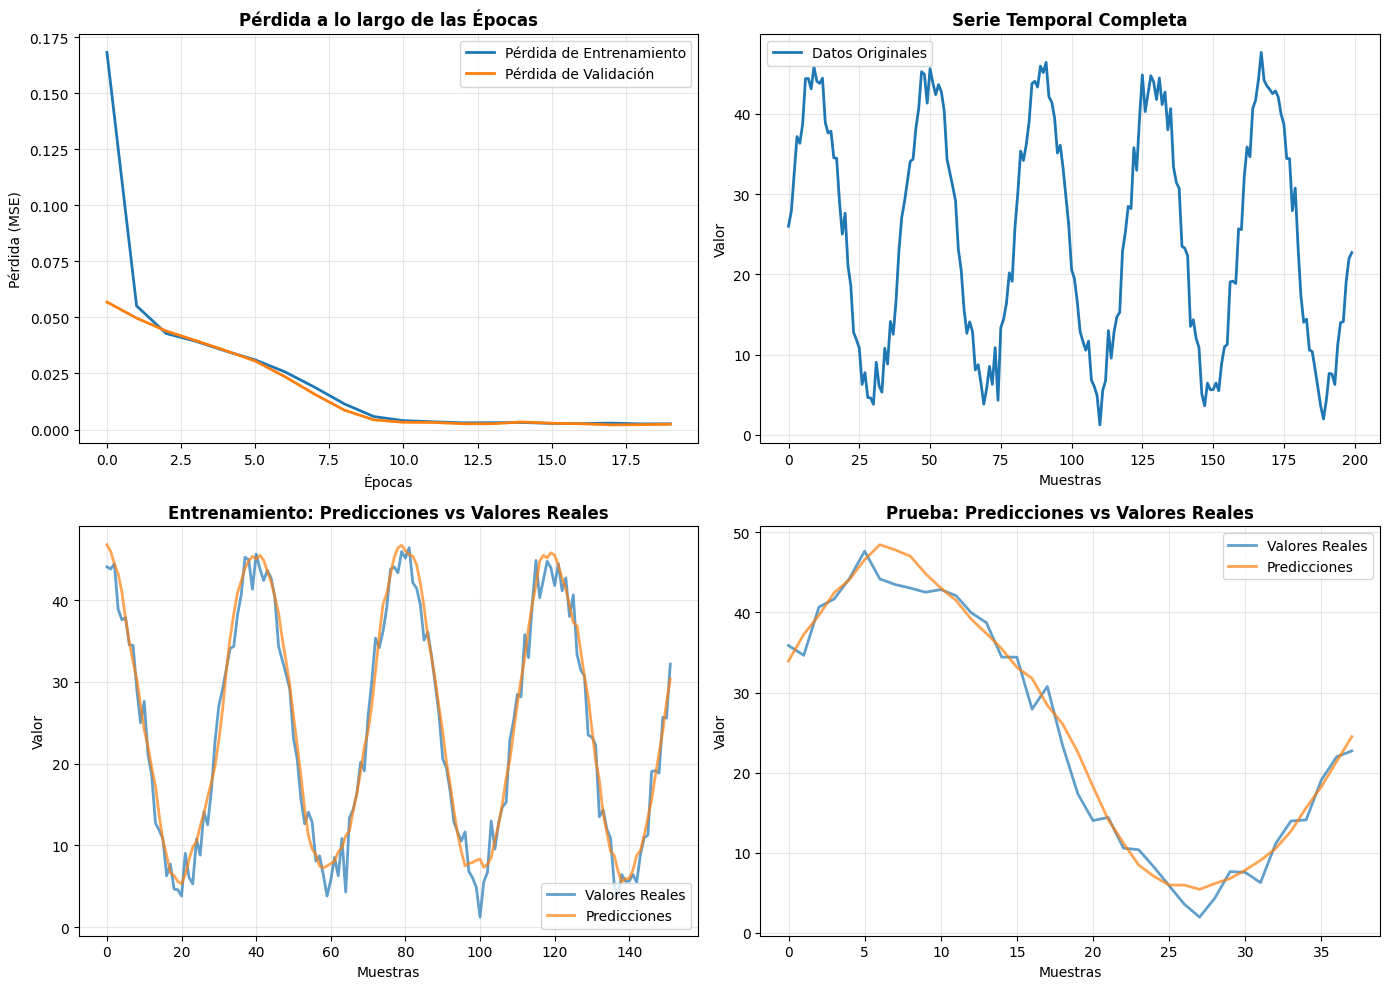


RESUMEN DE RESULTADOS - LSTM
Pérdida final de entrenamiento: 0.002553
Pérdida final de validación: 0.002357
RMSE en Entrenamiento: 2.415666
RMSE en Prueba: 2.253166
MAE en Prueba: 1.795358


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# Definimos los parámetros
input_size = 1        # Tamaño del vector de entrada (una característica)
hidden_size = 50      # Número de neuronas en la capa LSTM
output_size = 1       # Tamaño de la salida (predicción de un valor)
sequence_length = 10  # Longitud de la secuencia de entrada

# Creamos el modelo secuencial
model = Sequential()

# Añadimos una capa LSTM
# units: tamaño de la capa oculta, input_shape: forma de la entrada (longitud de la secuencia, tamaño de entrada)
model.add(LSTM(hidden_size, input_shape=(sequence_length, input_size)))

# Añadimos una capa de salida densa
model.add(Dense(output_size))

# Compilamos el modelo
model.compile(optimizer='adam', loss='mean_squared_error')

# Generamos datos sintéticos de series temporales (datos de temperatura simulados)
np.random.seed(42)
# Crear una serie temporal con patrón sinusoidal + ruido
time = np.linspace(0, 10*np.pi, 200)
data = np.sin(time) * 20 + np.random.normal(0, 2, len(time)) + 25
data = data.reshape(-1, 1)

# Normalizar los datos
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Crear secuencias para LSTM
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, sequence_length)

# Dividir en datos de entrenamiento y prueba (80-20)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Forma de X_train: {X_train.shape}")
print(f"Forma de y_train: {y_train.shape}")
print(f"Forma de X_test: {X_test.shape}")
print(f"Forma de y_test: {y_test.shape}")

# Entrenamos el modelo con los datos de entrenamiento
print("\nEntrenando el modelo...")
history = model.fit(X_train, y_train, epochs=20, batch_size=8, validation_data=(X_test, y_test), verbose=1)

# Realizamos predicciones con el modelo
print("\nRealizando predicciones...")
predictions_train = model.predict(X_train, verbose=0)
predictions_test = model.predict(X_test, verbose=0)

# Desnormalizar predicciones
predictions_train = scaler.inverse_transform(predictions_train)
predictions_test = scaler.inverse_transform(predictions_test)
y_train_real = scaler.inverse_transform(y_train)
y_test_real = scaler.inverse_transform(y_test)

# Mostrar las dimensiones de la salida
print(f"\nTamaño de las predicciones de prueba: {predictions_test.shape}")

# Visualizar resultados
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Pérdida de entrenamiento y validación
axes[0, 0].plot(history.history['loss'], label='Pérdida de Entrenamiento', linewidth=2)
axes[0, 0].plot(history.history['val_loss'], label='Pérdida de Validación', linewidth=2)
axes[0, 0].set_title('Pérdida a lo largo de las Épocas', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Épocas')
axes[0, 0].set_ylabel('Pérdida (MSE)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Gráfico 2: Serie temporal completa (datos originales)
axes[0, 1].plot(scaler.inverse_transform(scaled_data), label='Datos Originales', linewidth=2)
axes[0, 1].set_title('Serie Temporal Completa', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Muestras')
axes[0, 1].set_ylabel('Valor')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Gráfico 3: Predicciones vs Valores Reales (Entrenamiento)
axes[1, 0].plot(y_train_real, label='Valores Reales', linewidth=2, alpha=0.7)
axes[1, 0].plot(predictions_train, label='Predicciones', linewidth=2, alpha=0.7)
axes[1, 0].set_title('Entrenamiento: Predicciones vs Valores Reales', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Muestras')
axes[1, 0].set_ylabel('Valor')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Gráfico 4: Predicciones vs Valores Reales (Prueba)
axes[1, 1].plot(y_test_real, label='Valores Reales', linewidth=2, alpha=0.7)
axes[1, 1].plot(predictions_test, label='Predicciones', linewidth=2, alpha=0.7)
axes[1, 1].set_title('Prueba: Predicciones vs Valores Reales', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Muestras')
axes[1, 1].set_ylabel('Valor')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Calcular métricas de error
from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse_train = np.sqrt(mean_squared_error(y_train_real, predictions_train))
rmse_test = np.sqrt(mean_squared_error(y_test_real, predictions_test))
mae_test = mean_absolute_error(y_test_real, predictions_test)

# Resumen final
print(f"\n{'='*60}")
print("RESUMEN DE RESULTADOS - LSTM")
print(f"{'='*60}")
print(f"Pérdida final de entrenamiento: {history.history['loss'][-1]:.6f}")
print(f"Pérdida final de validación: {history.history['val_loss'][-1]:.6f}")
print(f"RMSE en Entrenamiento: {rmse_train:.6f}")
print(f"RMSE en Prueba: {rmse_test:.6f}")
print(f"MAE en Prueba: {mae_test:.6f}")
print(f"{'='*60}")

segunda parte

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896 (3.50 KB)

 Trainable params: 896 (3.50 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

Cargando dataset CIFAR-10...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Forma de train_images: (50000, 32, 32, 3)

Compilando el modelo...
Entrenando el modelo...
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 50s 153ms/step - accuracy: 0.2938 - loss: 1.9146 - val_accuracy: 0.4738 - val_loss: 1.4680
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 49s 156ms/step - accuracy: 0.5025 - loss: 1.3868 - val_accuracy: 0.5444 - val_loss: 1.2752
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 79s 147ms/step - accuracy: 0.5642 - loss: 1.2243 - val_accuracy: 0.5703 - val_loss: 1.2081
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 147ms/step - accuracy: 0.6044 - loss: 1.1207 - val_accuracy: 0.6256 - val_loss: 1.0771
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 143ms/step - accuracy: 0.6446 - loss: 1.0196 - val_accuracy: 0.6423 - val_loss: 1.0198

Evaluando en datos de prueba...
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6415 - loss: 1.0073
Test loss: 1.0184550285339355
Test accuracy: 0.6406999826431274


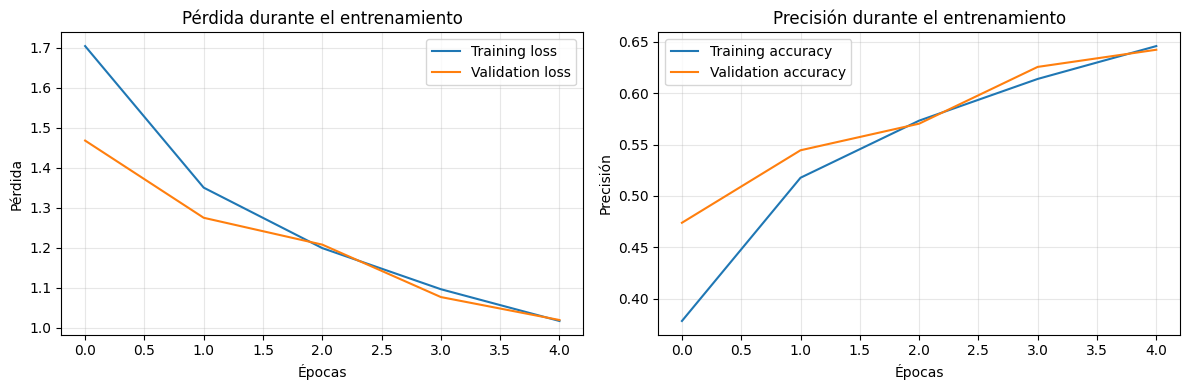


Realizando predicciones...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
Predicciones (primeras 10):
Imagen 0: Clase predicha = 3, Confianza = 0.5580
Imagen 1: Clase predicha = 8, Confianza = 0.6988
Imagen 2: Clase predicha = 8, Confianza = 0.6268
Imagen 3: Clase predicha = 0, Confianza = 0.7870
Imagen 4: Clase predicha = 6, Confianza = 0.5451
Imagen 5: Clase predicha = 6, Confianza = 0.6760
Imagen 6: Clase predicha = 1, Confianza = 0.4528
Imagen 7: Clase predicha = 6, Confianza = 0.5999
Imagen 8: Clase predicha = 3, Confianza = 0.4351
Imagen 9: Clase predicha = 1, Confianza = 0.9727


In [ ]:
import keras
keras.__version__
from keras import layers
from keras import models
from keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Construir modelo CNN
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.summary()

# Añadir más capas convolucionales
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.summary()

# Añadir más capas
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.summary()

# Aplanar y capas densas
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))
model.summary()

# Cargar el dataset CIFAR-10
print("Cargando dataset CIFAR-10...")
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

print("Forma de train_images:", train_images.shape)

# Preprocesar los datos
train_images = train_images.reshape((50000, 32, 32, 3))
train_images = train_images.astype('float32') / 255

test_images = test_images.reshape((10000, 32, 32, 3))
test_images = test_images.astype('float32') / 255

# Convertir etiquetas a formato categórico
train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

# Parámetros de entrenamiento
batch_size = 128
epochs = 5

# Compilar el modelo
print("\nCompilando el modelo...")
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# Entrenar el modelo
print("Entrenando el modelo...")
history = model.fit(train_images, train_labels,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_split=0.2)

# Evaluar en datos de prueba
print("\nEvaluando en datos de prueba...")
test_loss, test_acc = model.evaluate(test_images, test_labels)

print('Test loss:', test_loss)
print('Test accuracy:', test_acc)

# Visualizar pérdida y precisión
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('Precisión durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Realizar predicciones
print("\nRealizando predicciones...")
predictions = model.predict(test_images[:10])
print("Predicciones (primeras 10):")
for i, pred in enumerate(predictions):
    print(f"Imagen {i}: Clase predicha = {pred.argmax()}, Confianza = {pred.max():.4f}")